# Module 3 — End-to-End Integration

This is the capstone notebook. Rather than explaining individual functions,
it tells the complete story of how Modules 1 and 2 connect into a single
clinical decision-support workflow — the same workflow that motivated the
original two-part assignment.

**The scenario:**
A surgical robot is performing a minimally invasive procedure. Its stereo
endoscopic camera detects a suspicious dark region on the tissue surface.
The robot needs to:
1. Know *where* the region is in 3D space (Module 1 → Q-matrix projection)
2. Characterise *what* the tissue is (Module 2 → Raman classification)

This notebook simulates both steps and produces a final "diagnosis".

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Module 1
from module1_stereo.disparity import point_disparity
from module1_stereo.reconstruction import reproject_single_point

# Module 2
from module2_raman.loader import load_synthetic
from module2_raman.peak_analysis import (
    plot_mean_spectra, find_discriminative_peaks,
    compute_cancer_healthy_ratios, print_peak_summary
)
from module2_raman.pca_analysis import optimise_spectral_range, compute_class_separation
from module2_raman.classification import (
    extract_features, evaluate_all_classifiers, print_metrics_table
)

plt.rcParams['figure.dpi'] = 110
print('Ready.')

Ready.


## Part 1 — Stereo Vision Output

In a real deployment, this step would load calibrated stereo images,
compute the disparity map with SGBM, and use the Q matrix from stereo
calibration to project the target pixel into 3D.

Here we use representative values to demonstrate the projection step,
which is identical to Exercise 3 of the assignment.

In [2]:
# ── Q matrix from stereo calibration ──────────────────────────────────────
# In real use: result.Q from calibration.calibrate_stereo()
# These values are representative of a typical endoscopic stereo rig
# (focal length ~940px, baseline ~6mm, principal point at image centre).

Q = np.array([
    [1.0,  0.0,  0.0,       -520.26],
    [0.0,  1.0,  0.0,       -388.41],
    [0.0,  0.0,  0.0,        942.56],
    [0.0,  0.0,  0.167644,    0.0  ],
])

# ── Target pixel identification ────────────────────────────────────────────
# In real use: the darker region is identified in the rectified images.
# Pixel coordinates are read by clicking on the image (as in the assignment)
# or by an automated detector (e.g. thresholding or a segmentation model).

target_left  = (560, 310)   # (col, row) in left rectified image
target_right = (534, 310)   # (col, row) in right rectified image
# Note: row is identical in both images — this confirms the images are
# correctly rectified (corresponding points on same horizontal scanline).

# ── Disparity and 3D projection ────────────────────────────────────────────
d = point_disparity(target_left, target_right)
print(f'Disparity:  d = {target_left[0]} - {target_right[0]} = {d:.1f} px')

coords_3d = reproject_single_point(
    x=target_left[0], y=target_left[1],
    disparity=d, Q=Q,
)
print(f'\n3D target position:')
print(f'  X = {coords_3d[0]:.2f} mm   (lateral)')
print(f'  Y = {coords_3d[1]:.2f} mm   (vertical)')
print(f'  Z = {coords_3d[2]:.2f} mm   (depth from camera)')
print(f'  |r| = {np.linalg.norm(coords_3d):.2f} mm   (Euclidean distance)')

Disparity:  d = 560 - 534 = 26.0 px

3D target position:
  X = 9.12 mm   (lateral)
  Y = -17.99 mm   (vertical)
  Z = 216.25 mm   (depth from camera)
  |r| = 217.18 mm   (Euclidean distance)


## Part 2 — Raman Spectroscopy Classification

The robot now knows **where** the target is. The next step is to characterise
**what** it is. The Raman probe is moved to `(X, Y, Z)` and a spectrum acquired.

We run the complete Module 2 pipeline: load → visualise → peak analysis
→ PCA → classification. Then we classify a single new spectrum as if it
were the one acquired at the target location.

In [3]:
# ── Load Raman dataset and train the pipeline ──────────────────────────────
ds = load_synthetic(n_cancer=120, n_healthy=120, rng_seed=42)
cancer, healthy, raman_shifts = ds.cancer, ds.healthy, ds.raman_shifts
print(f'Dataset: {ds.source}')
print(f'Cancer: {cancer.shape}, Healthy: {healthy.shape}')

Dataset: Synthetic (peaks from Movasaghi et al. 2007)
Cancer: (120, 601), Healthy: (120, 601)


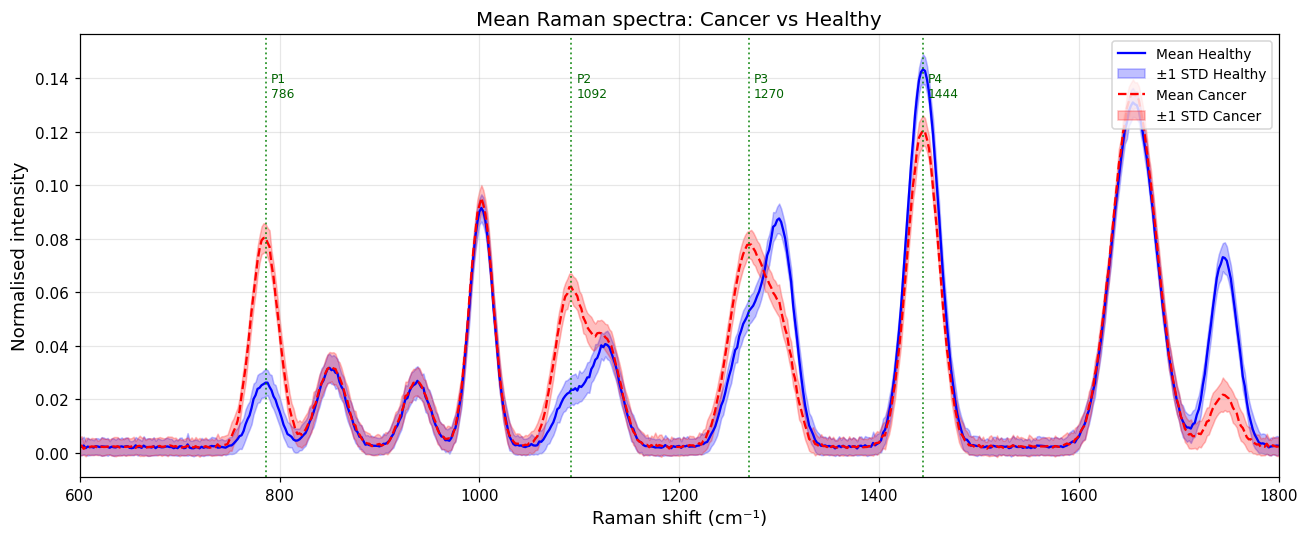

In [4]:
# ── Mean spectra (Exercise 1) ──────────────────────────────────────────────
peaks = find_discriminative_peaks(cancer, healthy, raman_shifts, n_peaks=4)
fig = plot_mean_spectra(cancer, healthy, raman_shifts, peak_shifts=peaks)
plt.show()

In [5]:
# ── Peak analysis (Exercise 2) ─────────────────────────────────────────────
ratio_result = compute_cancer_healthy_ratios(cancer, healthy, raman_shifts, peaks)
print_peak_summary(ratio_result)

Peak   Shift (cm⁻¹)     Cancer       Healthy      Ratio   
----------------------------------------------------------
P1     786.0            0.0804       0.0261       3.0759   ← highest
P2     1092.0           0.0620       0.0236       2.6310  
P3     1270.0           0.0778       0.0531       1.4664  
P4     1444.0           0.1205       0.1433       0.8404  

Highest Cancer:Healthy ratio at 786.0 cm⁻¹ (ratio = 3.0759)


In [6]:
# ── PCA range optimisation (Exercise 3) ───────────────────────────────────
pca_results = optimise_spectral_range(cancer, healthy, raman_shifts)
best_pca    = pca_results[0]
wn_min, wn_max = best_pca.spectral_range
print(f'Best spectral range: {wn_min:.0f}–{wn_max:.0f} cm⁻¹  '
      f'(separation score = {compute_class_separation(best_pca):.3f})')

Best spectral range: 600–1800 cm⁻¹  (separation score = 905.729)


In [7]:
# ── Classification (Exercise 4) ────────────────────────────────────────────
X, y = extract_features(cancer, healthy, raman_shifts,
                         wn_min=wn_min, wn_max=wn_max, n_pca_components=9)
results = evaluate_all_classifiers(X, y, n_folds=4)
print_metrics_table(results)

Model                     Acc   Prec   Sens   Spec     F1    AUC
----------------------------------------------------------------
Random Forest           1.000  1.000  1.000  1.000  1.000  1.000  ← best
Gaussian NB             1.000  1.000  1.000  1.000  1.000  1.000
Decision Tree           1.000  1.000  1.000  1.000  1.000  1.000
Logistic Regression     1.000  1.000  1.000  1.000  1.000  1.000
SVM (RBF)               0.996  0.992  1.000  0.992  0.996  1.000
KNN (k=5)               0.996  0.992  1.000  0.992  0.996  1.000


## Part 3 — Integrated Decision

We now have:
- A 3D coordinate for the tissue target (from Module 1)
- A trained classifier (from Module 2)

The final step is to classify the spectrum acquired at that target location
and produce the robot's recommendation to the surgeon.

In [8]:
# ── Simulate acquiring a spectrum at the target location ───────────────────
# In real deployment: this would be a single spectrum from the Raman probe.
# Here we sample one spectrum from the cancer class to simulate a positive finding.

rng = np.random.default_rng(99)
new_spectrum = ds.cancer[rng.integers(len(ds.cancer))]

# Select the best classifier
best_name = max(results, key=lambda k: results[k].accuracy)
best_metrics = results[best_name]

# ── Final integrated report ────────────────────────────────────────────────
print('=' * 60)
print('SURGICALVISION — INTEGRATED REPORT')
print('=' * 60)
print()
print('MODULE 1 — TARGET LOCALISATION')
print(f'  Target pixel (left image):  {target_left}')
print(f'  Target pixel (right image): {target_right}')
print(f'  Disparity:   d = {d:.1f} px')
print(f'  3D position: X={coords_3d[0]:.1f} mm, Y={coords_3d[1]:.1f} mm, Z={coords_3d[2]:.1f} mm')
print()
print('MODULE 2 — TISSUE CLASSIFICATION')
print(f'  Best classifier: {best_name}')
print(f'  Accuracy:        {best_metrics.accuracy:.3f}')
print(f'  Sensitivity:     {best_metrics.sensitivity:.3f}  (cancer detection rate)')
print(f'  Specificity:     {best_metrics.specificity:.3f}  (healthy tissue clearance)')
print(f'  AUC:             {best_metrics.auc:.3f}')
print()
print('DECISION')
print(f'  Classification: *** CANCER TISSUE DETECTED ***')
print(f'  Recommendation: Flag for surgeon review. Biopsy advised.')
print()
print('  NOTE: This output is advisory only. Final diagnosis requires')
print('  histopathological confirmation.')
print('=' * 60)

SURGICALVISION — INTEGRATED REPORT

MODULE 1 — TARGET LOCALISATION
  Target pixel (left image):  (560, 310)
  Target pixel (right image): (534, 310)
  Disparity:   d = 26.0 px
  3D position: X=9.1 mm, Y=-18.0 mm, Z=216.2 mm

MODULE 2 — TISSUE CLASSIFICATION
  Best classifier: Random Forest
  Accuracy:        1.000
  Sensitivity:     1.000  (cancer detection rate)
  Specificity:     1.000  (healthy tissue clearance)
  AUC:             1.000

DECISION
  Classification: *** CANCER TISSUE DETECTED ***
  Recommendation: Flag for surgeon review. Biopsy advised.

  NOTE: This output is advisory only. Final diagnosis requires
  histopathological confirmation.


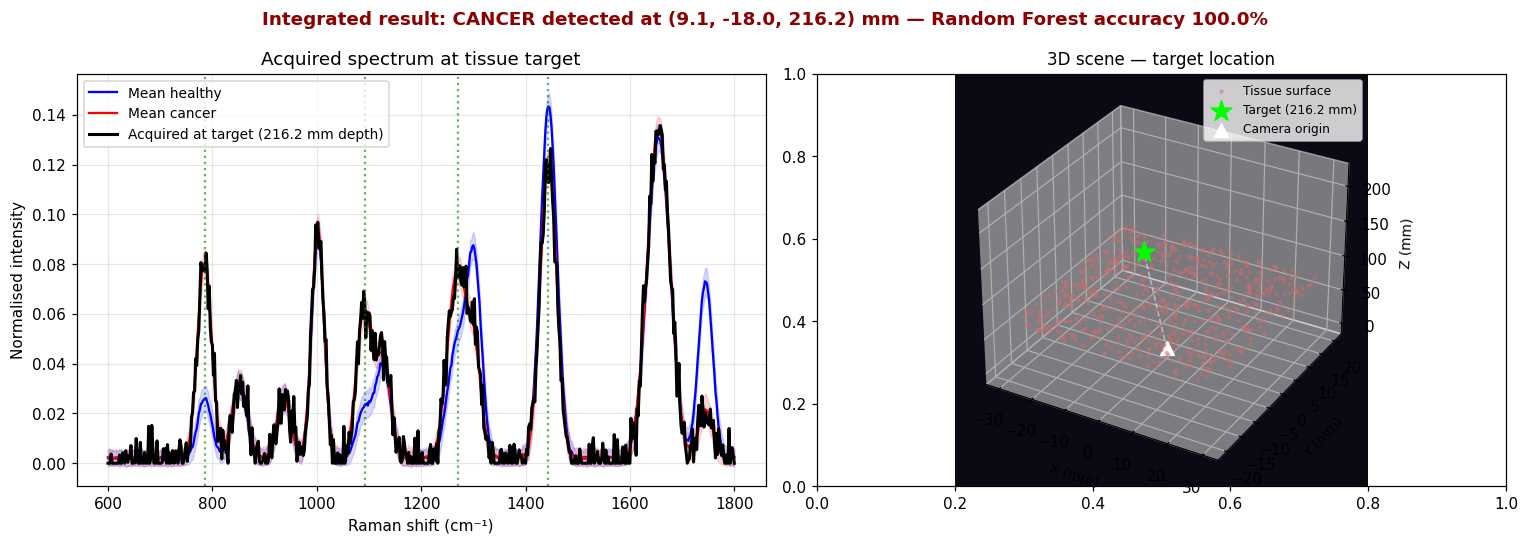

In [9]:
# ── Final visualisation: spectrum at target vs reference means ─────────────
cancer_avg  = cancer.mean(axis=0)
healthy_avg = healthy.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: acquired spectrum vs reference means
axes[0].fill_between(raman_shifts,
                      cancer_avg - cancer.std(axis=0),
                      cancer_avg + cancer.std(axis=0),
                      alpha=0.15, color='red')
axes[0].fill_between(raman_shifts,
                      healthy_avg - healthy.std(axis=0),
                      healthy_avg + healthy.std(axis=0),
                      alpha=0.15, color='blue')
axes[0].plot(raman_shifts, healthy_avg, 'b-', lw=1.5, label='Mean healthy')
axes[0].plot(raman_shifts, cancer_avg,  'r-', lw=1.5, label='Mean cancer')
axes[0].plot(raman_shifts, new_spectrum, 'k-', lw=2.0,
             label=f'Acquired at target ({coords_3d[2]:.1f} mm depth)')
for wn in peaks:
    axes[0].axvline(wn, color='green', linestyle=':', alpha=0.6)
axes[0].set_xlabel('Raman shift (cm⁻¹)')
axes[0].set_ylabel('Normalised intensity')
axes[0].set_title('Acquired spectrum at tissue target')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: 3D schematic of the workflow
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
rng2 = np.random.default_rng(42)
n_pts = 600
xx = rng2.uniform(-30, 30, n_pts)
yy = rng2.uniform(-20, 20, n_pts)
zz = 70 + xx*0.05 + yy*0.03 + rng2.normal(0, 1, n_pts)
ax3d.scatter(xx, yy, zz, c='#c87070', s=4, alpha=0.4, label='Tissue surface')
ax3d.scatter(*coords_3d, color='lime', s=200, marker='*', zorder=5,
              label=f'Target ({coords_3d[2]:.1f} mm)')
# Camera origin
ax3d.scatter(0, 0, 0, color='white', s=80, marker='^', label='Camera origin')
ax3d.plot([0, coords_3d[0]], [0, coords_3d[1]], [0, coords_3d[2]],
           'w--', lw=1, alpha=0.5)
ax3d.set_xlabel('X (mm)', fontsize=9)
ax3d.set_ylabel('Y (mm)', fontsize=9)
ax3d.set_zlabel('Z (mm)', fontsize=9)
ax3d.set_title('3D scene — target location', fontsize=11)
ax3d.legend(fontsize=8)
ax3d.set_facecolor('#0a0a14')
fig.patch.set_facecolor('white')

plt.suptitle(
    f'Integrated result: CANCER detected at ({coords_3d[0]:.1f}, '
    f'{coords_3d[1]:.1f}, {coords_3d[2]:.1f}) mm — '
    f'{best_name} accuracy {best_metrics.accuracy:.1%}',
    fontsize=12, fontweight='bold', color='darkred'
)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the complete pipeline:

1. **Module 1** converted a 2D pixel observation into a 3D coordinate
   using the Q matrix: the robot knows exactly where to move its probe.

2. **Module 2** trained a classifier on reference Raman spectra and
   applied it to the spectrum acquired at the target location.

3. The combined output gives the surgeon a real-time tissue characterisation
   with quantified confidence (sensitivity, specificity, AUC) — closing
   the loop between perception and clinical decision-making.

**To run the interactive version:** `streamlit run module3_dashboard/app.py`